In [212]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
import pandas as pd
import glob

In [213]:
def lineal0(x, a):
    return a * x

In [214]:
# Get data file names
filenames = glob.glob("calibration/10x10/*/*/pdd.out")

df10x10 = pd.DataFrame()
for filename in filenames:
    df10x10 = df10x10.add(pd.read_csv(filename, sep=r",", usecols=[2,3,4,5],
    names=['iZ','total', 'total^2','entries'], skiprows=4, engine="python"), fill_value=0)
df10x10=df10x10/np.size(filenames)

In [215]:
z_aux, eDep_aux = np.loadtxt('validation/experimental/10x10/pdd',delimiter="\t",usecols =(0, 1),unpack=True)
exp10x10 = interp1d(z_aux, eDep_aux,kind="slinear")
z10x10 = np.linspace(3, 330.0, 325)

In [216]:
K0='6MV'
zMax=500 # cm
nBins=125
scale=zMax/nBins
df10x10['iZ']=zMax-(df10x10['iZ'])*scale-2

In [217]:
iZ=df10x10['iZ']
filter = (iZ >= np.min(z10x10)) & (iZ <= np.max(z10x10))

In [218]:
# Initial guesses for parameters a and b
initial_guess = [1e14]

# Apply curve fitting
try:
    popt, pcov = curve_fit(lineal0, np.array(df10x10['total'][filter]),np.array(exp10x10(iZ[filter])), p0=initial_guess)
    print("Optimal parameters (a, b):", popt)
    print("Covariance of parameters:", pcov)
except Exception as e:
    print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [4.2526388e+14]
Covariance of parameters: [[5.01553078e+22]]


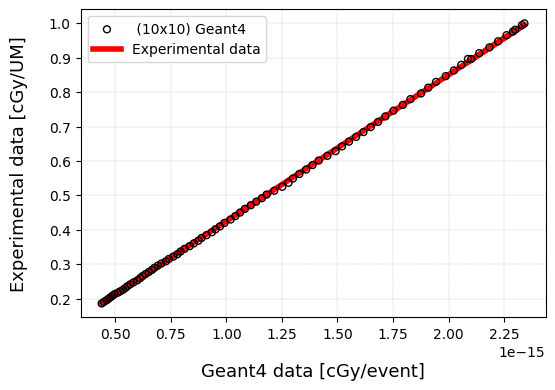

In [219]:
fig=plt.figure(figsize=(6,4))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Geant4 data [cGy/event]', fontsize=13,labelpad=15)
ax1.set_ylabel('Experimental data [cGy/UM]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)
ax1.scatter(df10x10['total'][filter],exp10x10(iZ[filter]), s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.plot(df10x10['total'][filter], lineal0(df10x10['total'][filter], *popt), linestyle="-", linewidth=4, color="red", ms=5,zorder=2,label="Experimental data")
ax1.legend(loc='best')


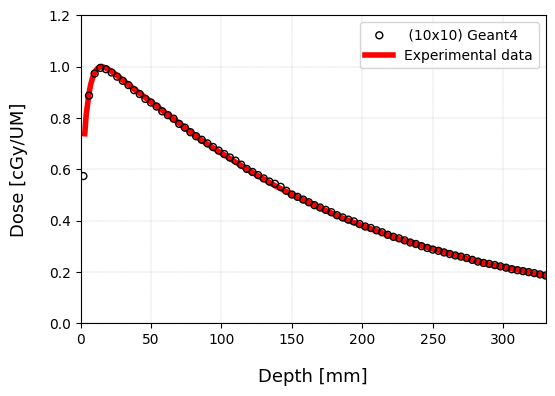

In [220]:
fig=plt.figure(figsize=(6,4))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(0,1.2)
ax1.scatter(df10x10['iZ'], df10x10['total']*popt[0], s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=5)
ax1.plot(z10x10, exp10x10(z10x10), linestyle="-", linewidth=4, color="red", ms=5,zorder=2,label="Experimental data")
ax1.legend(loc='best')


In [221]:
iZ = np.array(iZ[filter])
diff10x10=((exp10x10(iZ))-(df10x10['total'][filter]*popt[0]))/(exp10x10(iZ))

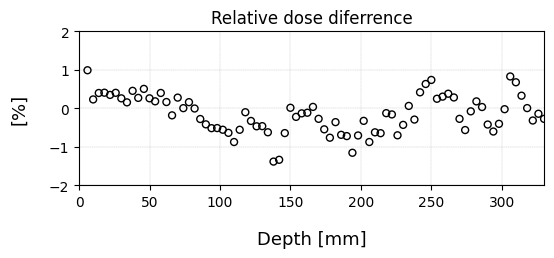

In [222]:
fig=plt.figure(figsize=(6,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('Depth [mm]', fontsize=13,labelpad=15)
ax1.set_ylabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Relative dose diferrence')
ax1.grid(linestyle='--', linewidth=0.25)
ax1.set_xlim(0,330)
ax1.set_ylim(-2,2)
ax1.scatter(iZ, diff10x10*100, s=25, facecolors='none', edgecolors='black', label=" (10x10) Geant4",zorder=4)#
#plt.plot(iZ.reshape(-1, 1), reg.predict(iZ.reshape(-1, 1))*100, color='blue',linewidth=4)
#ax1.legend(loc='best')


(array([ 3.,  0.,  7., 14., 14., 15., 11., 13.,  3.,  2.]),
 array([-0.01380386, -0.01143128, -0.0090587 , -0.00668612, -0.00431354,
        -0.00194096,  0.00043162,  0.0028042 ,  0.00517678,  0.00754936,
         0.00992194]),
 <BarContainer object of 10 artists>)

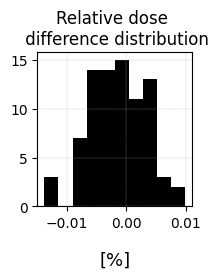

In [223]:
fig=plt.figure(figsize=(2,2))

ax1=fig.add_subplot(111)
ax1.set_xlabel('[%]', fontsize=13,labelpad=15)
ax1.set_title('Relative dose \n difference distribution')
ax1.grid(linestyle='--', linewidth=0.25)
#ax1.set_xlim(0,330)
#ax1.set_ylim(-0.1,0.1)
plt.hist(diff10x10, color='black')
#ax1.legend(loc='best')



In [228]:
print("Simulation calibration factor [cGy/ev -> cGy/UM (dmax)] = ",100/popt[0])

Simulation calibration factor [cGy/ev -> cGy/UM (dmax)] =  2.3514811546434146e-13
